# Machine Learning Modeling - Churn Prediction

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import time

# Set random seed 
np.random.seed(42)

In [2]:
sys.path.append(os.path.abspath('..'))

from src.models import (
    LogisticRegression, 
    KNearestNeighbors, 
    NaiveBayes, 
    RandomForest,
    ModelEvaluator
)
from src.data_processing import load_processed_data
from src.visualization import DataVisualizer

visualizer = DataVisualizer()

# Load Data + Training

In [3]:
def load_data(version):
    X_train = load_processed_data(f'../data/processed/X_train_{version}.npy')
    X_test = load_processed_data(f'../data/processed/X_test_{version}.npy')
    y_train = load_processed_data(f'../data/processed/y_train_{version}.npy')
    y_test = load_processed_data(f'../data/processed/y_test_{version}.npy')
    return X_train, X_test, y_train, y_test

def train_model(model, X_train, y_train, X_test, y_test):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    y_pred_test = model.predict(X_test)
    test_acc = ModelEvaluator.accuracy(y_test, y_pred_test)
    metrics = ModelEvaluator.precision_recall_f1(y_test, y_pred_test)
    
    return {
        'test_acc': test_acc,
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1': metrics['f1_score'],
        'time': train_time
    }

def get_models():
    models = {
        'Logistic Regression': LogisticRegression(learning_rate=0.1, n_iterations=500, regularization=0.01),
        'KNN': KNearestNeighbors(k=5),
        'Naive Bayes': NaiveBayes(),
        'Random Forest': RandomForest(n_estimators=50, max_depth=10)
    }
    return models

# Train on Basic Dataset

In [4]:
X_train_b, X_test_b, y_train_b, y_test_b = load_data('basic')

Loaded processed data from ../data/processed/X_train_basic.npy
Loaded processed data from ../data/processed/X_test_basic.npy
Loaded processed data from ../data/processed/y_train_basic.npy
Loaded processed data from ../data/processed/y_test_basic.npy


In [5]:
results_basic = {}
for name, model in get_models().items():
    print(f'Training {name}...')
    results_basic[name] = train_model(model, X_train_b, y_train_b, X_test_b, y_test_b)
    print(f"  Acc: {results_basic[name]['test_acc']:.4f}, F1: {results_basic[name]['f1']:.4f}")

Training Logistic Regression...
  Acc: 0.8889, F1: 0.5731
Training KNN...
  Acc: 0.9012, F1: 0.6255
Training Naive Bayes...
  Acc: 0.8716, F1: 0.5975
Training Random Forest...
  Acc: 0.9457, F1: 0.8103


# Train on Enhanced Dataset

In [6]:
X_train_e, X_test_e, y_train_e, y_test_e = load_data('enhanced')

Loaded processed data from ../data/processed/X_train_enhanced.npy
Loaded processed data from ../data/processed/X_test_enhanced.npy
Loaded processed data from ../data/processed/y_train_enhanced.npy
Loaded processed data from ../data/processed/y_test_enhanced.npy


In [7]:
results_enhanced = {}
for name, model in get_models().items():
    print(f'Training {name}...')
    results_enhanced[name] = train_model(model, X_train_e, y_train_e, X_test_e, y_test_e)
    print(f"  Acc: {results_enhanced[name]['test_acc']:.4f}, F1: {results_enhanced[name]['f1']:.4f}")

Training Logistic Regression...
  Acc: 0.8574, F1: 0.8591
Training KNN...
  Acc: 0.9232, F1: 0.9290
Training Naive Bayes...
  Acc: 0.8294, F1: 0.8307
Training Random Forest...
  Acc: 0.9671, F1: 0.9676


# Results Comparison

In [8]:
print(f"{'Model':<20} {'Version':<10} {'Acc':>8} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Time(s)':>9}")
print('-' * 85)
for name in results_basic.keys():
    r_b = results_basic[name]
    r_e = results_enhanced[name]
    print(f"{name:<20} {'Basic':<10} {r_b['test_acc']:>8.4f} {r_b['precision']:>10.4f} {r_b['recall']:>8.4f} {r_b['f1']:>8.4f} {r_b['time']:>9.4f}")
    print(f"{name:<20} {'Enhanced':<10} {r_e['test_acc']:>8.4f} {r_e['precision']:>10.4f} {r_e['recall']:>8.4f} {r_e['f1']:>8.4f} {r_e['time']:>9.4f}")
    print('-' * 85)

Model                Version         Acc  Precision   Recall       F1   Time(s)
-------------------------------------------------------------------------------------
Logistic Regression  Basic        0.8889     0.7550   0.4618   0.5731    0.2942
Logistic Regression  Enhanced     0.8574     0.8599   0.8584   0.8591    0.2075
-------------------------------------------------------------------------------------
KNN                  Basic        0.9012     0.8068   0.5107   0.6255    0.0000
KNN                  Enhanced     0.9232     0.8741   0.9913   0.9290    0.0000
-------------------------------------------------------------------------------------
Naive Bayes          Basic        0.8716     0.6050   0.5902   0.5975    0.0020
Naive Bayes          Enhanced     0.8294     0.8356   0.8259   0.8307    0.0020
-------------------------------------------------------------------------------------
Random Forest        Basic        0.9457     0.9289   0.7187   0.8103  105.4473
Random Forest   

# Visualization

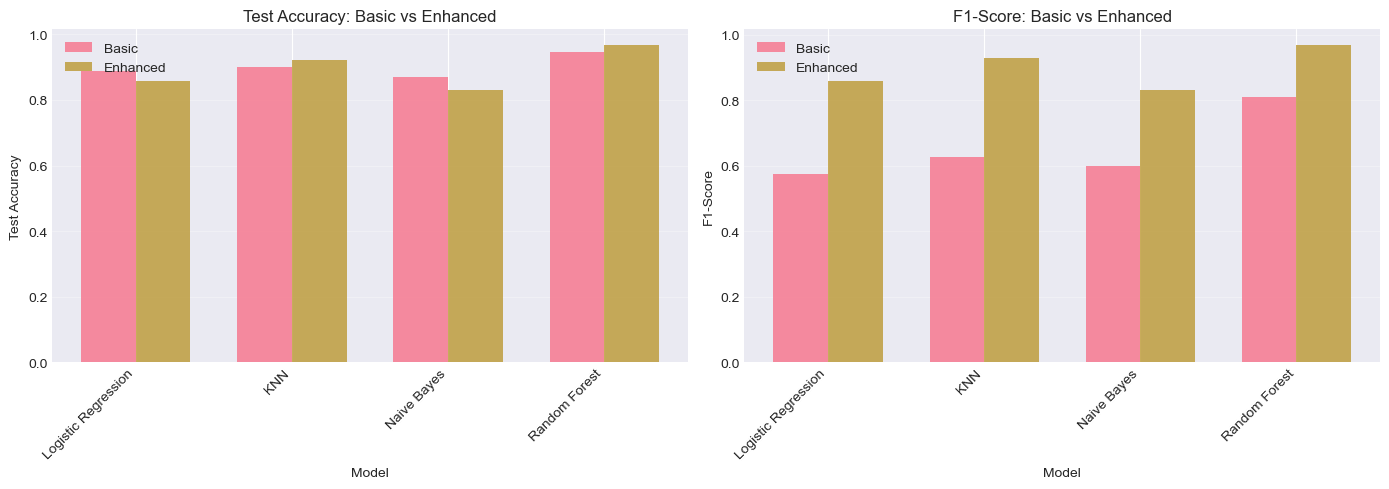

In [19]:
visualizer.plot_model_comparison(results_basic, results_enhanced)
plt.show()

# Cross Validation

In [10]:
from src.models import cross_validate

print("Performing 5-Fold Cross-Validation on Enhanced Dataset")
print(f"{'Model':<20} {'Mean Acc':>10} {'Std Dev':>10} {'Min Acc':>10} {'Max Acc':>10}")
print('-' * 70)

cv_models = get_models()
cv_results = {}

for name, model in cv_models.items():
    cv_result = cross_validate(model, X_train_e, y_train_e, k=5, metric='accuracy')
    cv_results[name] = cv_result
    print(f"{name:<20} {cv_result['mean']:>10.4f} {cv_result['std']:>10.4f} {cv_result['min']:>10.4f} {cv_result['max']:>10.4f}")

Performing 5-Fold Cross-Validation on Enhanced Dataset
Model                  Mean Acc    Std Dev    Min Acc    Max Acc
----------------------------------------------------------------------
Logistic Regression      0.8532     0.0041     0.8460     0.8581
KNN                      0.9143     0.0048     0.9088     0.9221
Naive Bayes              0.8138     0.0078     0.8026     0.8257
Random Forest            0.9651     0.0033     0.9614     0.9706


# Model Analysis & Insights


In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = ModelEvaluator.confusion_matrix(y_true, y_pred, n_classes=2)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=['Not Churned', 'Churned'],
           yticklabels=['Not Churned', 'Churned'],
           title=title,
           ylabel='Actual',
           xlabel='Predicted')
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            text = ax.text(j, i, cm[i, j],
                          ha="center", va="center",
                          color="white" if cm[i, j] > cm.max() / 2 else "black",
                          fontsize=20, fontweight='bold')
    
    plt.tight_layout()
    return fig, cm
